<a href="https://colab.research.google.com/github/gsferreira-tec/vcomp/blob/main/assignment-1/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

### Authors

- Guilherme Sousa Ferreira - **Student ID**: up201706719
- Diogo Loayza Duarte - **Student ID**: up2021...
---


In [2]:
from google.colab import drive
drive.mount('/content/drive/')

from pathlib import Path
# Setup the relevant directory/subdirectories for the assignment
root_dir = Path('/content/drive/MyDrive/VCOMP/Assignment-1')
calib_dir = root_dir/'Calibration'
fault_dir = root_dir/'Faults'
isolated_dir = root_dir/'Isolated'
kit_dir = root_dir/'Kit'


Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


## ***Task 1 - "Calibration Images"***
## **a)**
 - We are asked to present the intrinsic matrix, the lens distortion coefficients and the re-projection error.
 - Afterwards we select the best calibration and justify the selection with 2 sentences.
---

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow
import glob2 # used to get all the images in a directory path into a list

# define paths to calibration folders
calib_1 = calib_dir/'calib1'
calib_2 = calib_dir/'calib2'
calib_3 = calib_dir/'calib3'

# build a function to go through all the calib directories and the images within and extract the metrics asked
# - Intrinsic Matrix
# - Lens distortion coefficients
# - Re-projection error
def parameter_extraction(directory, checkerboard_size=(11,8), square_size=15):
    image_list = list(directory.glob('*.png')) # get all the from the path provided (calib1, calib2, calib3, ...)
    #if needed we could format the images to have the same formatting(jpeg, png, etc.)

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # in order to know if the calibration is correct we must create a prediction/model for what the correct checkerboard should be
    # this should be especcially important to measure the lens distortion by comparing that with the modeled "tr uth"
    objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

    # lists to store corresponding object point and image points
    objpoints = []
    imgpoints = []

    for image in image_list:
        img_bgr = cv2.imread(str(image)) # read the image

        # for computational efficiency and accuracy we will work with grayscale image
        img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

        # after reading we find the corners
        ret, corners = cv2.findChessboardCorners(img_gray, checkerboard_size, None)

        # ret==True means that findChessboardCorners was successfull and therefore we can append the corners to a list with the object points used (objp) and the correponding "corners" (image_points) to use (2D projection)
        if ret == True:
            objpoints.append(objp)
            imgpoints.append(corners)

    # calling this function returns the metrics we need to display
    ret, mtx, dist, rvecs, tvecs = cv2.calibrateCamera(objpoints, imgpoints, img_gray.shape[::-1], None, None)

    # return the re-projecyion error, the intrinsic matrix and the lens DISTortion coefficients, respetively
    return ret, mtx, dist

# Next step we use the function to determine these parameters for every calibration attempt and display them
ret_1, mtx_1, dist_1 = parameter_extraction(calib_1)
ret_2, mtx_2, dist_2 = parameter_extraction(calib_2)
ret_3, mtx_3, dist_3 = parameter_extraction(calib_3)

# displaying the results
results = [
    ("CALIBRATION 1", ret_1, mtx_1, dist_1),
    ("CALIBRATION 2", ret_2, mtx_2, dist_2),
    ("CALIBRATION 3", ret_3, mtx_3, dist_3)
]

for name, ret, mtx, dist in results:
    if ret is not None:
        print(f"**** {name} ****")
        print(f"Re-Projection Error: {ret:.4f}\n")
        print(f"Intrinsic Matrix:\n{np.round(mtx,2)}\n")
        print(f"Lens Distortion: {np.round(dist.ravel(), 4)}\n")
    else:
        print(f"**** {name} **** FAILED!")

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


**** CALIBRATION 1 ****
Re-Projection Error: 0.3315

Intrinsic Matrix:
[[836.79   0.   342.87]
 [  0.   837.   281.47]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.246e-01  3.059e-01 -1.100e-03  1.000e-04 -3.226e-01]

**** CALIBRATION 2 ****
Re-Projection Error: 0.6156

Intrinsic Matrix:
[[846.79   0.   346.94]
 [  0.   847.14 277.27]
 [  0.     0.     1.  ]]

Lens Distortion: [-0.4326  0.2551  0.0005 -0.0017  0.0133]

**** CALIBRATION 3 ****
Re-Projection Error: 0.6838

Intrinsic Matrix:
[[837.9    0.   340.52]
 [  0.   838.32 276.98]
 [  0.     0.     1.  ]]

Lens Distortion: [-4.098e-01  1.841e-01 -3.000e-04  1.000e-04  7.240e-02]



**Answer:**
- Analysing the results of the three calibration attempts we can safely say that the attempt that yielded the best results was **Calibration 1**.

**Justification:**

- In comparison to the others, calibration 1 has by far the lowest re-projection error (0.3315 compared to 0.6156 or 0.6838).
- This means that the values determined for the **Intrinsic Matrix** and the **Lens Distortion Coefficients**, in calibration 1, add up to a better representation of the limitations of the camera which in turn allow us to compensate for those imperfections with much better accuracy.

---
## **b)**
- "final_setup.png" represents the final inspection arrangement. Calibrate the extrinsic parameters of the camera setup. Present the extrinsic matrix and specify the pixel-to-milimeter conversion factor applied.

In [4]:
"""
After a prompt in Gemini I find that the function that allows the computation of the extrinsic parameter matrix is the function in OpenCV called solvePnP
or solve Perpective-n-Point.

This function will allow us to determine the parameters that delineate the physical position of the camera relative to the table.

It takes as arguments object points model created in the previous step, the corners of the final_setup.png image which also have to be determined
and the parameters of the imperfections determined for the calibration selected (mtx_1 and dist_1).
"""

# path of the final_setup image
img_path = calib_dir
final_setup_img = cv2.imread(str(img_path/'final_setup.png'))

# convert to gray scale for the same reason as previously stated
gray_setup_img = cv2.cvtColor(final_setup_img, cv2.COLOR_BGR2GRAY)

# build the checkerboard's "true" model
checkerboard_size=(11,8)
square_size = 15
objp = np.zeros((checkerboard_size[0] * checkerboard_size[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:checkerboard_size[0], 0:checkerboard_size[1]].T.reshape(-1,2) * square_size

# lists to store corresponding object point and image points
objpoints = []
imgpoints = []

# determine the corners for the image
ret, final_corners = cv2.findChessboardCorners(gray_setup_img, checkerboard_size, None)

if ret == True:
    # determine the extrinsic parameters/matrix
    ret_2, rvec, tvec = cv2.solvePnP(objp, final_corners, mtx_1, dist_1)

    R_matrix , _ = cv2.Rodrigues(rvec)
    ext_mtx = np.hstack((R_matrix, tvec))

    print("Extrinsic Matrix:\n", np.round(ext_mtx, 3))
else:
    print("No corners were found in the image...\n")

Extrinsic Matrix:
 [[-9.98000e-01 -1.20000e-02 -5.90000e-02  6.30500e+01]
 [ 9.00000e-03 -9.98000e-01  6.00000e-02  3.40230e+01]
 [-5.90000e-02  6.00000e-02  9.96000e-01  2.66468e+02]]


In [5]:
"""
Now to determine the pixel to mm conversion ratio used we can apply the euclidian distance formula to figure out the distance between pixels and then compare
that with the actual distance used which is given as 15mm.
"""

# determining 2 points
corner_point_1 = final_corners[0][0]
corner_point_2 = final_corners[1][0]

# determine the distance between these 2 point using numpy
pxl_distance = np.linalg.norm(corner_point_1-corner_point_2)

# determine the conversion ratio
conversion_ratio = 15/pxl_distance

# display the ratio used
print(f"Conversion Factor: {conversion_ratio:.4f}\n")

Conversion Factor: 0.3453



## ***Task 2 - "Isolated Brick Images"***
## **a)**
- Define an ROI for the image.

ROI 1: x = 207.0000; y = 340.0000; weight= 135.0000; height= 133.0000.
ROI 2: x = 359.0000; y = 292.0000; weight= 136.0000; height= 136.0000.
ROI 3: x = 60.0000; y = 262.0000; weight= 111.0000; height= 113.0000.
ROI 4: x = 175.0000; y = 187.0000; weight= 135.0000; height= 135.0000.
ROI 5: x = 366.0000; y = 108.0000; weight= 203.0000; height= 190.0000.
ROI 6: x = 14.0000; y = 69.0000; weight= 206.0000; height= 147.0000.
ROI 7: x = 280.0000; y = 15.0000; weight= 112.0000; height= 115.0000.


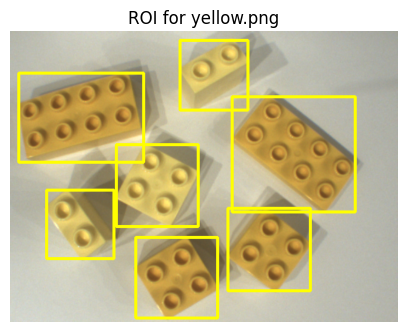

ROI 1: x = 290.0000; y = 324.0000; weight= 134.0000; height= 133.0000.
ROI 2: x = 89.0000; y = 311.0000; weight= 149.0000; height= 169.0000.
ROI 3: x = 444.0000; y = 236.0000; weight= 147.0000; height= 129.0000.
ROI 4: x = 380.0000; y = 140.0000; weight= 62.0000; height= 111.0000.
ROI 5: x = 194.0000; y = 135.0000; weight= 137.0000; height= 136.0000.
ROI 6: x = 7.0000; y = 96.0000; weight= 118.0000; height= 208.0000.
ROI 7: x = 481.0000; y = 69.0000; weight= 124.0000; height= 128.0000.
ROI 8: x = 137.0000; y = 12.0000; weight= 293.0000; height= 99.0000.


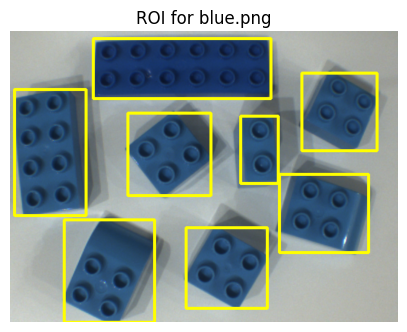

ROI 1: x = 246.0000; y = 323.0000; weight= 126.0000; height= 128.0000.
ROI 2: x = 431.0000; y = 167.0000; weight= 198.0000; height= 204.0000.
ROI 3: x = 269.0000; y = 136.0000; weight= 111.0000; height= 110.0000.
ROI 4: x = 64.0000; y = 98.0000; weight= 134.0000; height= 135.0000.
ROI 5: x = 358.0000; y = 11.0000; weight= 111.0000; height= 112.0000.


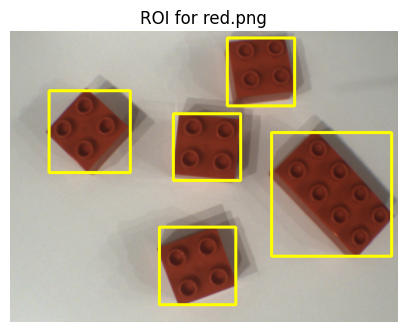

ROI 1: x = 165.0000; y = 354.0000; weight= 101.0000; height= 100.0000.
ROI 2: x = 335.0000; y = 300.0000; weight= 116.0000; height= 116.0000.
ROI 3: x = 416.0000; y = 160.0000; weight= 116.0000; height= 109.0000.
ROI 4: x = 65.0000; y = 118.0000; weight= 210.0000; height= 151.0000.
ROI 5: x = 242.0000; y = 25.0000; weight= 129.0000; height= 128.0000.
ROI 6: x = 422.0000; y = 11.0000; weight= 102.0000; height= 109.0000.


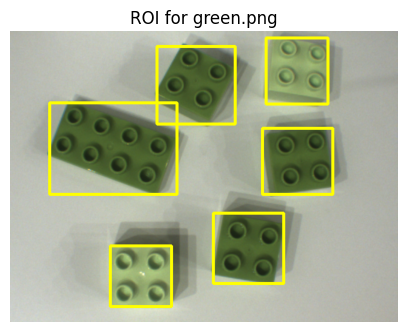

In [10]:
"""
Taking a look at the images we notice that using a single ROI for all of them is not feasible since the bricks are positioned in different positions and they are also different
amounts and sizes...

Since this is the case we must create an ROI for each image (and each brick) and for this we create the following function.
"""

def determine_roi(directory):
    #define the image list
    image_list = [img for img in directory.glob('*.png') if img.name != 'colored_bricks.png']

    # ---- DEBUG ----
    if len(image_list) == 0:
        print("Something went wrong. The image list is empty.\n")
        return None, None, None

    # iterate through the images to create ROIs for each
    for img_path in image_list:
        # reading the original image
        img = cv2.imread(str(img_path))

        # convert the image to rgb for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # process the images (blue, red and green) or (yellow)
        #if 'yellow' in img_path.name.lower():
            #split the channels of the image to look at the blue
            #b, g, r = cv2.split(img)

            # blur the image
            #blurred =cv2.GaussianBlur(b, (7,7), 0)

            # determine the mask and optimal threshold
            #_ , mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

        if 'yellow' in img_path.name.lower():
            # convert the image to LAB color space (apparently it works better than the previous method which gets confused with the shadows)
            img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

            # split the channels to isolate the b channel (Blue-Yellow)
            l, a, b = cv2.split(img_lab)

            # blur the split b channel
            blurred = cv2.GaussianBlur(b, (7,7), 0)

            # determine the mask and optimal limit
            _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        else:
            # if the image is not yellow we use the HSV color space
            img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
            h, s, c = cv2.split(img_hsv)

            # blur the saturation channel of the HSV image to ignore veru fine details
            blurred = cv2.GaussianBlur(s, (5,5), 0)

            # determine a mask and the optimal threshold
            _, mask = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

        # for any of the colors build the kernel and clean up the blurred masks for noise (in case of overlappign components for example)
        noise_kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel, iterations=2)

        # close the gaps in the mask (filling holes inside the bricks)
        kernel = np.ones((9,9), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        # determine the contours
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for i, contour in enumerate(contours):
            x, y, w, h = cv2.boundingRect(contour)

            if (w * h) > 3500:
                print(f"ROI {i+1}: x = {x:.4f}; y = {y:.4f}; weight= {w:.4f}; height= {h:.4f}.")
                cv2.rectangle(img_rgb, (x, y), (x+w, y+h), color=(255, 255, 0), thickness=3)

        # finally we display the ROIs for visual debug
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"ROI for {img_path.name}")
        plt.axis("off")
        plt.show()

# call the function for the 'Isolated' directory
determine_roi(isolated_dir)

## **b)**
- For image "colored_bricks.png", count the number of bricks grouped by color.


Final Count:

Red: 2
Yellow: 3
Green: 3
Blue: 2


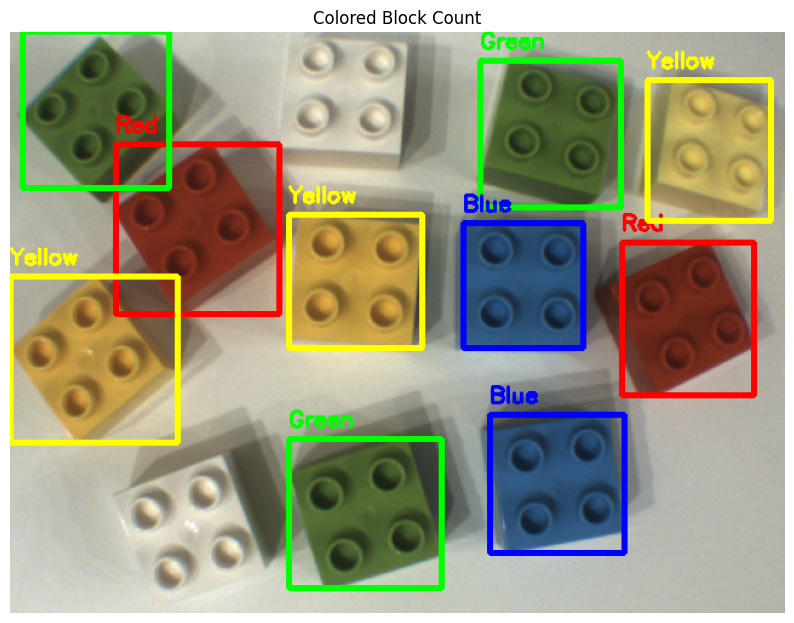

In [12]:
def color_brick_counter(img_path):
    img = cv2.imread(str(img_path))

    # ----------- DEBUG ----------
    if img is None:
        print(f"Could not load image at {img_path}")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) # for plots
    img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # definition of color ranges for the different bricks
    color_ranges = {
        'Red': [ ([0,100,100], [10, 255, 255]), ([160, 100, 100], [180, 255, 255])],
        'Yellow': [([15, 100, 100], [35, 255, 255])],
        'Green': [([40, 50, 50], [90, 255, 255])],
        'Blue': [([100, 100, 50], [140, 255, 255])],
    }

    color_counts = {'Red': 0, 'Yellow': 0, 'Green': 0, 'Blue': 0} # where the final count of bricks per color will be stored

    box_colors = {
        'Red': (255, 0, 0),
        'Yellow': (255, 255, 0),
        'Green': (0, 255, 0),
        'Blue': (0, 0, 255)
    }

    # iterate through the colors to detect the contours corresponding to the current color
    for color_name, ranges in color_ranges.items():

        # create a black mask
        mask = np.zeros(img_hsv.shape[:2], dtype="uint8")

        # apply the ranges
        for (lower, upper) in ranges:
            # create arrays with the upper and lower limits of the color_ranges
            lower_np = np.array(lower, dtype="uint8")
            upper_np = np.array(upper, dtype="uint8")

            # do bitwise_or on the mask
            mask = cv2.bitwise_or(mask, cv2.inRange(img_hsv, lower_np, upper_np))

        # morph open to clean up the mask
        noise_kernel = np.ones((5,5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, noise_kernel, iterations=1)

        # morph close
        close_kernel = np.ones((9,9), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, close_kernel, iterations=2)

        # determine the contours on the mask
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # count the bricks and draw boxes around them
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)

            # ignore very small details by specifying a min area
            if (w * h) > 3500:
                color_counts[color_name]+=1

                # draw the rect around the brick
                cv2.rectangle(img_rgb, (x,y), (x+w, y+h), box_colors[color_name], 4)

                # label the rectable with the name of the color
                cv2.putText(img_rgb, color_name, (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, box_colors[color_name], 2)

    # finally display the results
    print("Final Count:\n")
    for color, count in color_counts.items():
        print(f"{color}: {count}")
    # plot the final image (img_rgb)
    plt.figure(figsize=(10, 10))
    plt.imshow(img_rgb)
    plt.title("Colored Block Count")
    plt.axis("off")
    plt.show()

color_brick_counter(isolated_dir/'colored_bricks.png')



| Size | Avg Area (pixel)| Avg Area (mm) | Std Deviation (mm) |
|------|-----------------|---------------|--------------------|
| 2x1  |                 |               |                    |
| 2x2  |                 |               |                    |
| 2x4  |                 |               |                    |
| 2x6  |                 |               |                    |
| R2x2 |                 |               |                    |